# Iirise lillede analüüs

## impordid ja seadistused

In [12]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## laeme sisse andmed

In [4]:
iris = pd.read_csv("iris.csv")
iris

,sepal_length,sepal width,petal_length,petal width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [6]:
duckdb.sql("""
           select *
           from 'iris.csv'
           """)

┌──────────────┬─────────────┬──────────────┬─────────────┬───────────┐
│ sepal_length │ sepal width │ petal_length │ petal width │  species  │
│    double    │   double    │    double    │   double    │  varchar  │
├──────────────┼─────────────┼──────────────┼─────────────┼───────────┤
│          5.1 │         3.5 │          1.4 │         0.2 │ setosa    │
│          4.9 │         3.0 │          1.4 │         0.2 │ setosa    │
│          4.7 │         3.2 │          1.3 │         0.2 │ setosa    │
│          4.6 │         3.1 │          1.5 │         0.2 │ setosa    │
│          5.0 │         3.6 │          1.4 │         0.2 │ setosa    │
│          5.4 │         3.9 │          1.7 │         0.4 │ setosa    │
│          4.6 │         3.4 │          1.4 │         0.3 │ setosa    │
│          5.0 │         3.4 │          1.5 │         0.2 │ setosa    │
│          4.4 │         2.9 │          1.4 │         0.2 │ setosa    │
│          4.9 │         3.1 │          1.5 │         0.1 │ seto

## avastuslik andmeanalüüs(*exploratory analysis)

hea alusatda alati käsuga SUMMARIZE

In [7]:
duckdb.sql("""
           summarize iris
           """).df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,sepal_length,DOUBLE,4.3,7.9,35,5.843333333333335,0.8280661279778637,5.1,5.8,6.4,150,0.0
1,sepal width,DOUBLE,2.0,4.4,26,3.057333333333334,0.4358662849366979,2.8,3.0,3.3249999999999997,150,0.0
2,petal_length,DOUBLE,1.0,6.9,39,3.7580000000000027,1.7652982332594664,1.5750000000000002,4.35,5.1,150,0.0
3,petal width,DOUBLE,0.1,2.5,23,1.199333333333334,0.7622376689603467,0.3,1.3,1.8,150,0.0
4,species,VARCHAR,setosa,virginica,3,NaN,NaN,NaN,NaN,NaN,150,0.0


<Axes: xlabel='species', ylabel='count'>

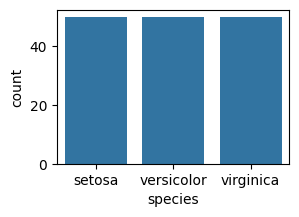

In [16]:
plt.figure(1, figsize=(3,2))
sns.countplot(data=iris, x="species")

In [18]:
duckdb.sql("""
           select species, count(*) as COUNT
           from iris
           group by species
           """)

┌────────────┬───────┐
│  species   │ COUNT │
│  varchar   │ int64 │
├────────────┼───────┤
│ setosa     │    50 │
│ versicolor │    50 │
│ virginica  │    50 │
└────────────┴───────┘

<Axes: xlabel='sepal_length', ylabel='sepal width'>

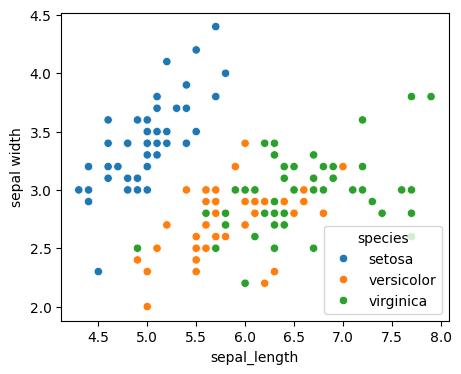

In [27]:
fig = plt.figure(1, figsize=(5, 4))
sns.scatterplot(data=iris, x="sepal_length", y="sepal width", hue="species")


## tondigraafik

In [34]:
?sns.kdeplot

Signature:
sns.kdeplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    fill=None,
    multiple='layer',
    common_norm=True,
    common_grid=False,
    cumulative=False,
    bw_method='scott',
    bw_adjust=1,
    warn_singular=True,
    log_scale=None,
    levels=10,
    thresh=0.05,
    gridsize=200,
    cut=3,
    clip=None,
    legend=True,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate distributions using kernel density estimation.

A kernel density estimate (KDE) plot is a method for visualizing the
distribution of observations in a dataset, analogous to a histogram. KDE
represents the data using a continuous probability density curve in one or
more dimensions.

The approach is explained further in the :ref:`user guide <tutorial_kde>`.

Relative to a histogram, KDE can produce a plot that is less cl

<Axes: xlabel='petal_length', ylabel='Density'>

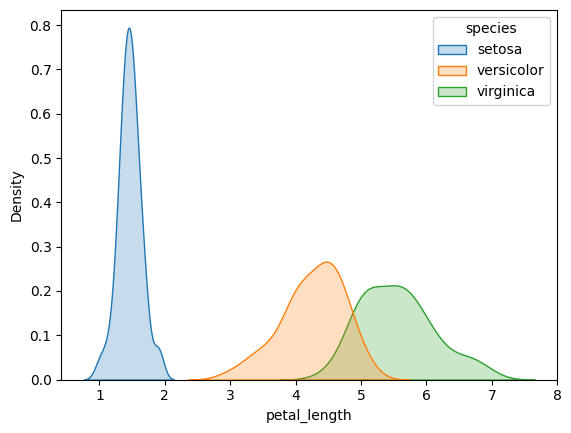

In [28]:
sns.kdeplot(data=iris, x="petal_length", hue="species", fill=True)

<Axes: xlabel='petal_length', ylabel='petal width'>

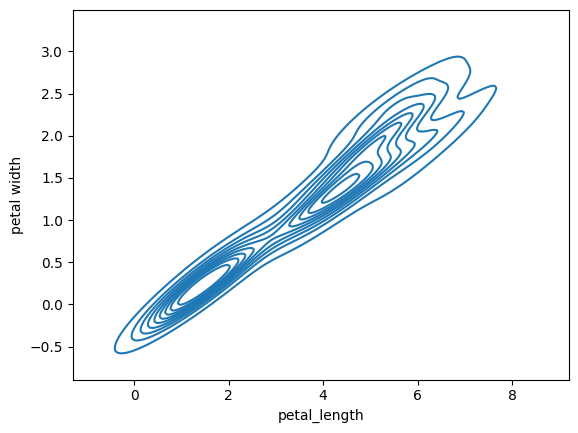

In [31]:
sns.kdeplot(data=iris, x="petal_length", y="petal width")


<Axes: xlabel='sepal_length', ylabel='sepal width'>

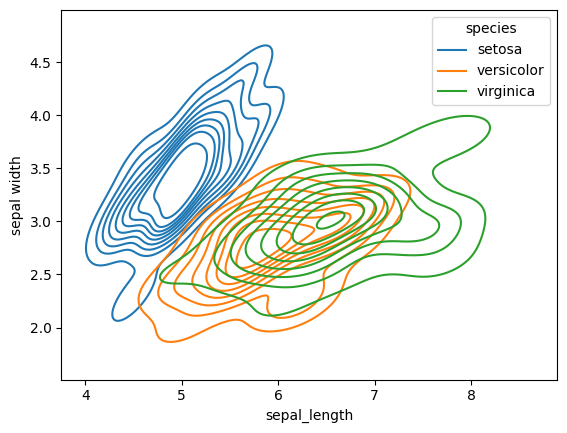

In [33]:
sns.kdeplot(data=iris, x="sepal_length", y="sepal width", hue="species")

## pairplot

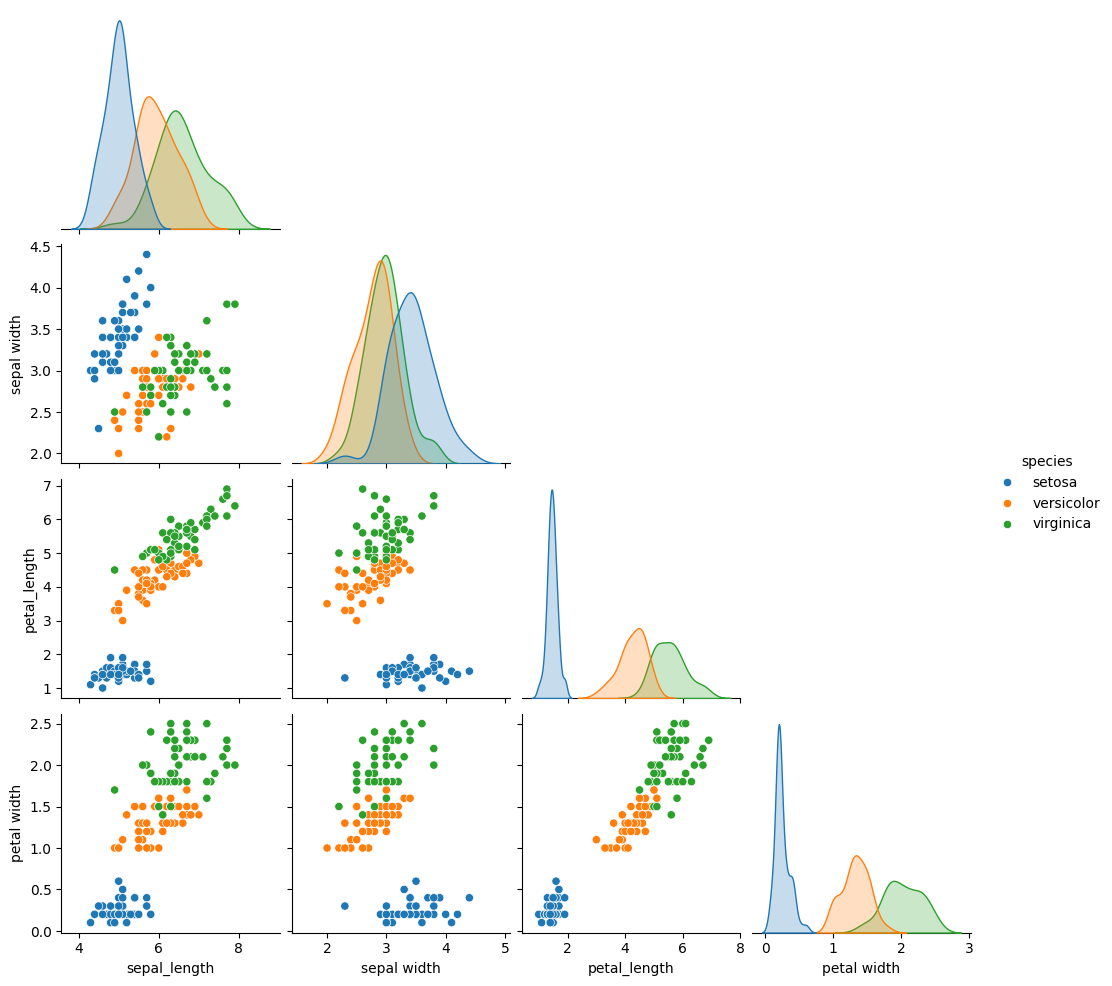

In [36]:
sns.pairplot(iris, hue="species", corner = True)

## boxplot 

näitab ühe tunnuse jaotust, joonsinise kasti keskel = mediaanvärtus, pool mahub kasti ära, pool ei mahu.
 
need kes sinna ka ei mahu, märgitakse üksikute punktidena

<Axes: xlabel='petal_length'>

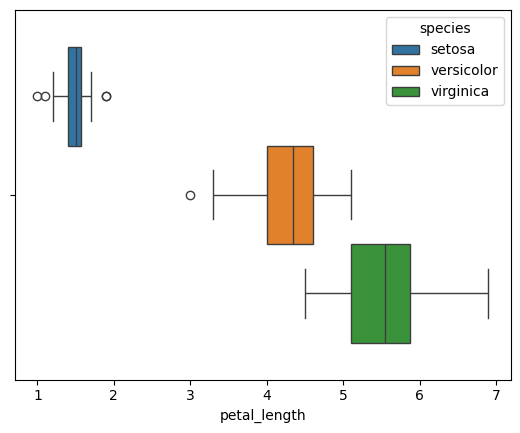

In [39]:
sns.boxplot(data=iris,  x="petal_length", hue="species")

<Axes: xlabel='petal_length'>

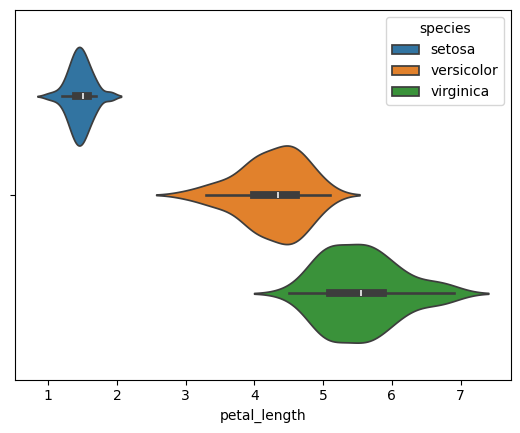

In [40]:
sns.violinplot(data=iris,  x="petal_length", hue="species")

<Axes: ylabel='species'>

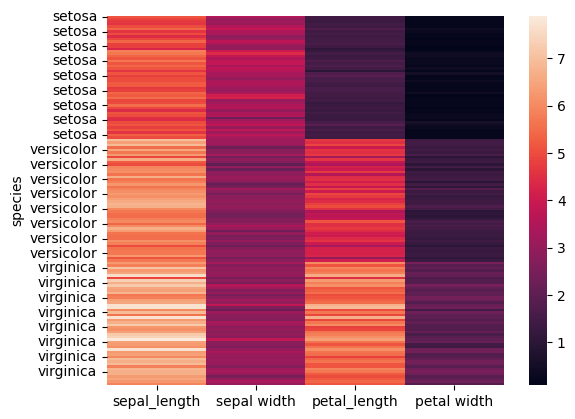

In [43]:
sns.heatmap(iris.set_index("species"))

<Axes: ylabel='species'>

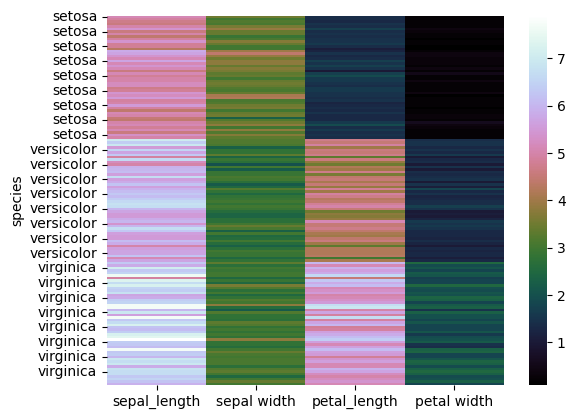

In [52]:
sns.heatmap(
    iris.set_index("species"),
    cmap="cubehelix")